# Train GB quantile models

Three models, same two-phase setup (LightGBM mean, then residual P10 / P50 / P90).

- **Next hour** — ERA5 weather plus the last one and two settlement periods of INDO/ND.
- **Next day** — Previous Runs weather, leads 0–24h only.
- **Next week** — Previous Runs weather, leads 0–7 days. No 30/60-minute demand lags.

Last eight weeks are held out of each fit.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from energy_forecast.forecast import prepare_history
from energy_forecast.model import predict_quantiles, train_day_models, train_hour_models, train_models

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
frame = prepare_history()
frame[["timestamp", "demand_mw", "temperature_2m", "hdd", "demand_lag_48"]].head()

,timestamp,demand_mw,temperature_2m,hdd,demand_lag_48
0,2024-01-01 00:00:00+00:00,21681,6.625,8.875,22232.0
1,2024-01-01 00:00:00+00:00,21681,8.550,6.950,22232.0
2,2024-01-01 00:00:00+00:00,21681,8.825,6.675,22232.0
3,2024-01-01 00:00:00+00:00,21681,9.625,5.875,22232.0
4,2024-01-01 00:00:00+00:00,21681,8.625,6.875,22232.0


In [3]:
models, metrics = train_models(frame)
metrics

,metric,quantile,value
0,pinball,0.1,237.218067
1,pinball,0.5,505.205008
2,mae,0.5,1010.410016
3,pinball,0.9,212.091171
4,coverage_80,0.8,0.805690
5,interval_scale,0.8,1.663071


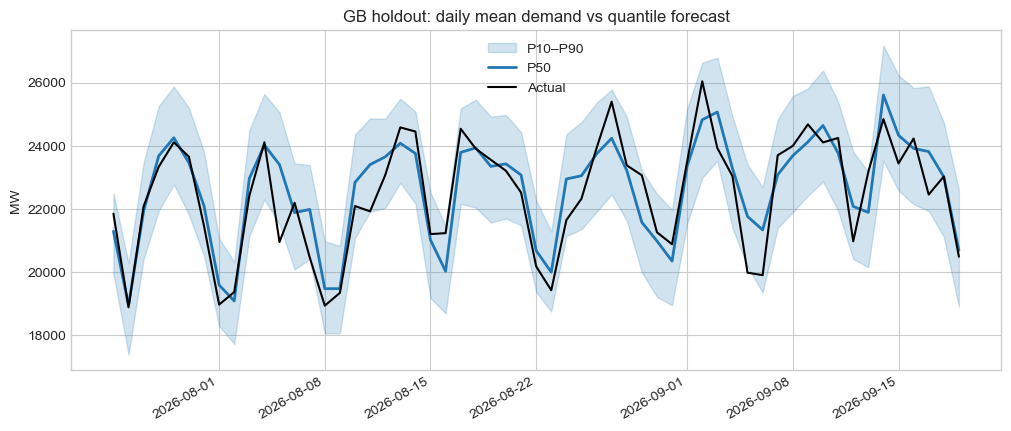

In [4]:
holdout_start = pd.Timestamp(models.metadata["holdout_start"])
holdout = frame[frame["timestamp"] >= holdout_start].copy()
scored = predict_quantiles(holdout, models).sort_values("timestamp")
daily = (
    scored.assign(date=pd.to_datetime(scored["settlement_date"]).dt.normalize())
    .groupby("date", as_index=False)[["demand_mw", "p10", "p50", "p90"]]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(daily["date"], daily["p10"], daily["p90"], color="tab:blue", alpha=0.2, label="P10–P90")
ax.plot(daily["date"], daily["p50"], color="tab:blue", linewidth=2, label="P50")
ax.plot(daily["date"], daily["demand_mw"], color="black", linewidth=1.5, label="Actual")
ax.set_title("GB holdout: daily mean demand vs quantile forecast")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()

In [ ]:
hour_frame = prepare_history(weather_source="archive")
hour_models, hour_metrics = train_hour_models(hour_frame)
hour_metrics

In [ ]:
day_models, day_metrics = train_day_models(frame)
day_metrics

In [ ]:
hour_holdout_start = pd.Timestamp(hour_models.metadata["holdout_start"])
hour_holdout = hour_frame[hour_frame["timestamp"] >= hour_holdout_start].copy()
hour_scored = predict_quantiles(hour_holdout, hour_models).sort_values("timestamp")
hour_daily = (
    hour_scored.assign(date=pd.to_datetime(hour_scored["settlement_date"]).dt.normalize())
    .groupby("date", as_index=False)[["demand_mw", "p10", "p50", "p90"]]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(hour_daily["date"], hour_daily["p10"], hour_daily["p90"], color="tab:green", alpha=0.2, label="P10–P90")
ax.plot(hour_daily["date"], hour_daily["p50"], color="tab:green", linewidth=2, label="P50")
ax.plot(hour_daily["date"], hour_daily["demand_mw"], color="black", linewidth=1.5, label="Actual")
ax.set_title("Next-hour holdout: daily mean demand vs quantile forecast")
ax.set_ylabel("MW")
ax.legend()
fig.autofmt_xdate()
plt.show()